<h1 align="center"><b>      Parkinson’s Disease Prediction using Exploratory Data Analysis (EDA), Machine Learning, and Deep Learning</b></h1>


# The objective of this project is to analyze biomedical voice measurements to distinguish between individuals with Parkinson’s disease and healthy subjects. Through Exploratory Data Analysis (EDA), key patterns and differences are identified within the dataset. Furthermore, Machine Learning and Deep Learning techniques are applied to develop predictive models that enhance the early detection and diagnosis of Parkinson’s disease.
</p>

# 1. Import All Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = 'colab'
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             classification_report)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')
import joblib
import os
print(" All libraries imported successfully!")

 All libraries imported successfully!


# 2. Load the Parkinson’s Dataset

In [6]:
df = pd.read_csv("/content/parkinsons.data")

In [7]:
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [8]:
df.shape

(195, 24)

# 3. Dataset Information

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [10]:
df.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


In [12]:
df.isnull().sum()

,0
name,0
MDVP:Fo(Hz),0
MDVP:Fhi(Hz),0
MDVP:Flo(Hz),0
MDVP:Jitter(%),0
MDVP:Jitter(Abs),0
MDVP:RAP,0
MDVP:PPQ,0
Jitter:DDP,0
MDVP:Shimmer,0


In [ ]:
# Check for duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")

# 4. Data Cleaning and Preprocessing

# 4.1 Remove Non‑Feature Columns

In [14]:
if 'name' in df.columns:
    df = df.drop('name', axis=1)
print("Columns after dropping 'name':", df.columns.tolist())

Columns after dropping 'name': ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']


# 4.2 Separate Features and Target

In [15]:
# Target column: 'status' (1 = Parkinson's, 0 = Healthy)
X = df.drop('status', axis=1)
y = df['status']
print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")

Features shape: (195, 22)
Target distribution:
status
1    147
0     48
Name: count, dtype: int64


# 4.3 Train‑Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 156 samples
Test set: 39 samples


# 4.4 Feature Scaling

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(" Features scaled.")

 Features scaled.


# 5. Exploratory Data Analysis (EDA)

# 5.1 Class Distribution

In [18]:
fig = px.pie(names=y.value_counts().index, values=y.value_counts().values,
             title='Parkinson’s Disease Status Distribution',
             color_discrete_sequence=['lightblue','coral'])
fig.show()

# 5.2 Distribution of Voice Features

In [19]:
# Select first 6 features for demonstration
features = X.columns[:6]
fig = make_subplots(rows=2, cols=3, subplot_titles=features)

for i, col in enumerate(features):
    row = i // 3 + 1
    col_pos = i % 3 + 1
    fig.add_trace(go.Histogram(x=X[col], name=col, marker_color='lightgreen'), row=row, col=col_pos)

fig.update_layout(height=600, title_text='Distribution of Selected Voice Features')
fig.show()

# 5.3 Boxplot Comparison: PD vs Healthy

In [20]:
# Select a few important features
selected = ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Shimmer', 'HNR']

fig = make_subplots(rows=2, cols=3, subplot_titles=selected)

for i, col in enumerate(selected):
    row = i // 3 + 1
    col_pos = i % 3 + 1
    fig.add_trace(go.Box(x=df['status'], y=df[col], name=col, showlegend=False), row=row, col=col_pos)

fig.update_layout(height=600, title_text='Voice Feature Distribution: PD vs Healthy')
fig.show()

# 5.4 Correlation Heatmap

In [21]:
# Select top 10 features by variance
variance = X.var()
top_features = variance.nlargest(10).index
X_top = X[top_features]

corr_matrix = X_top.corr()
fig = px.imshow(corr_matrix, text_auto=True, aspect='auto',
                title='Correlation Heatmap of Top 10 Features',
                color_continuous_scale='RdBu', zmin=-1, zmax=1)
fig.show()

# 5.5 Pairplot of Selected Features (Seaborn)

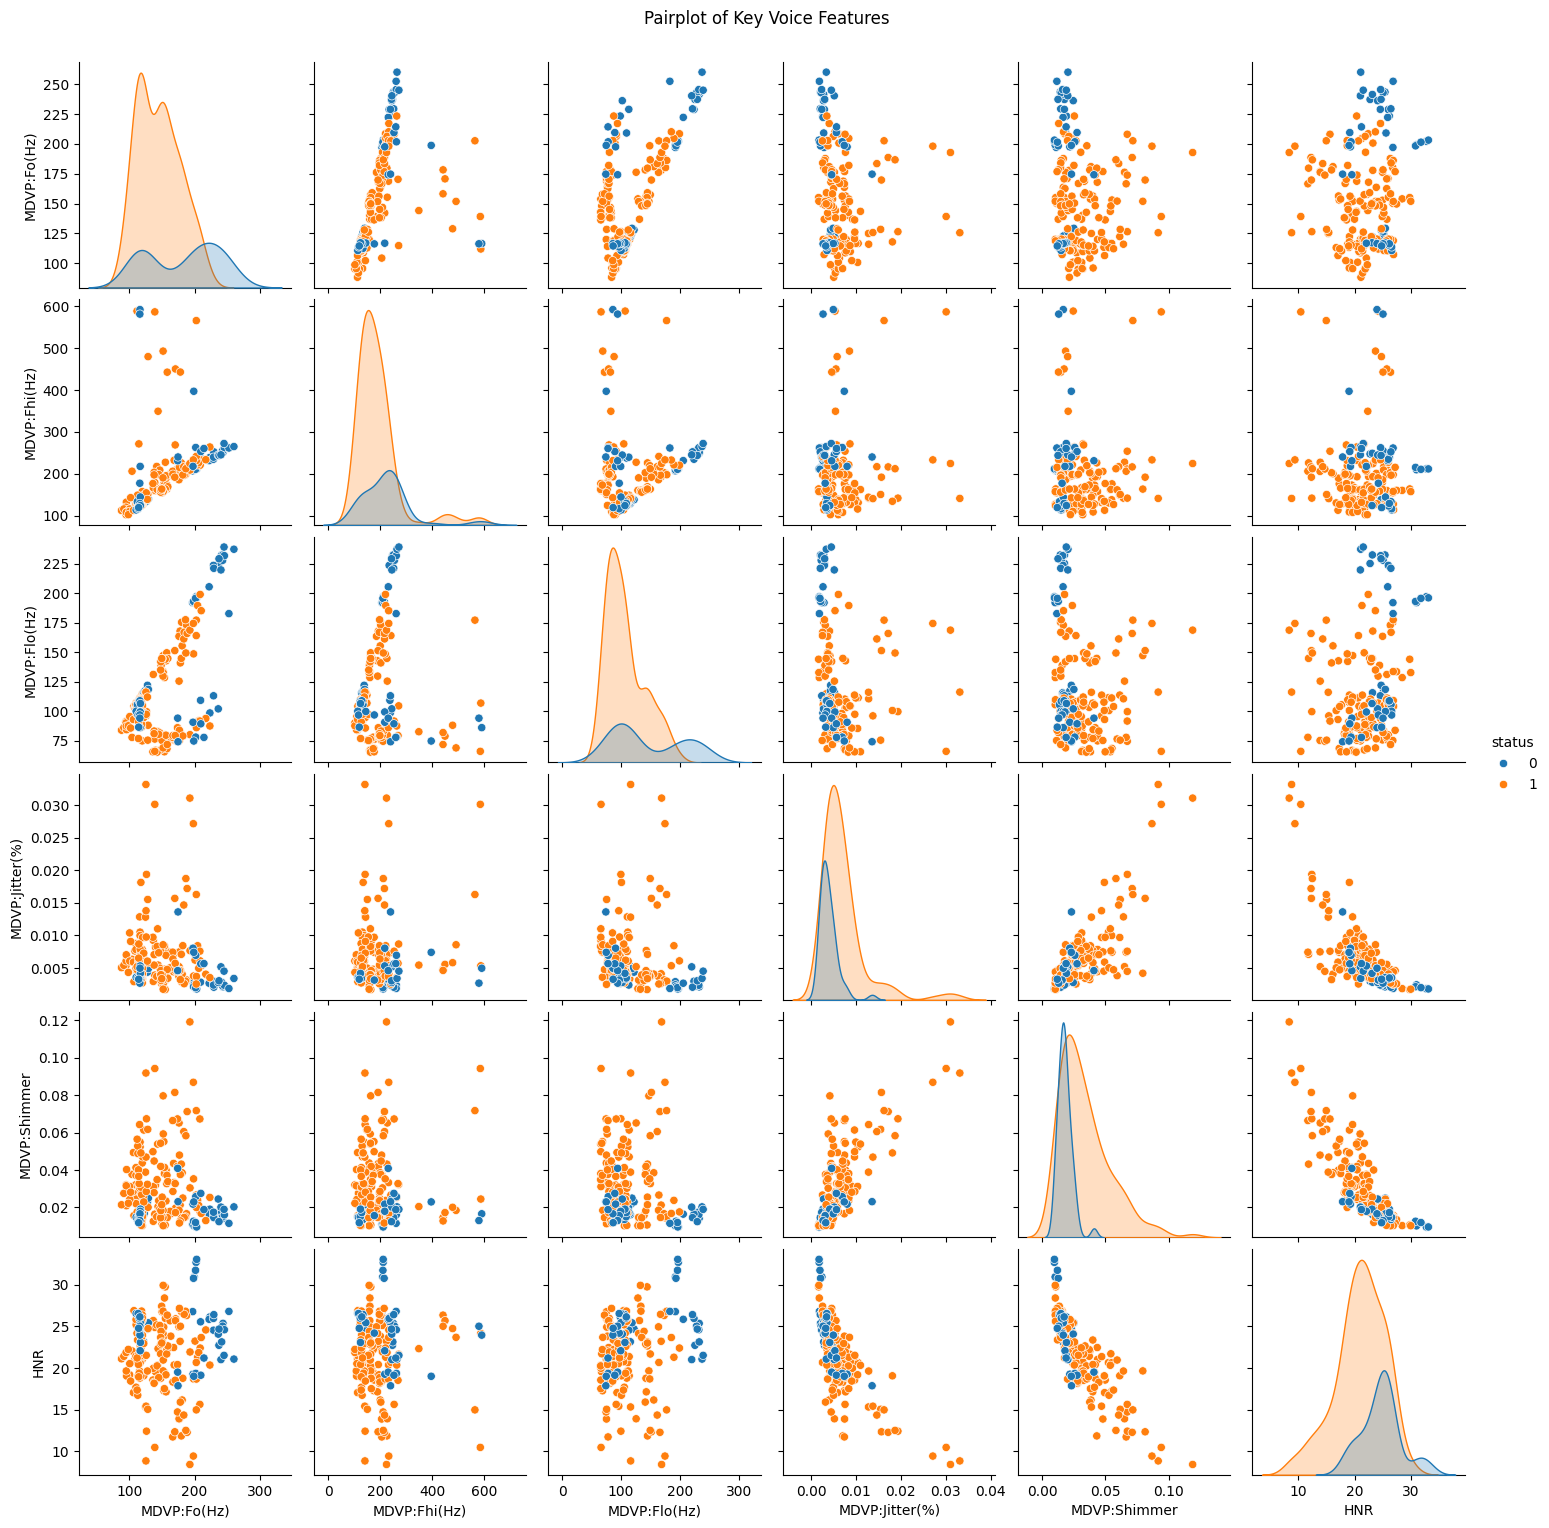

In [22]:
# Pairplot for a small subset
sns.pairplot(df[selected + ['status']], hue='status', diag_kind='kde')
plt.suptitle('Pairplot of Key Voice Features', y=1.02)
plt.show()

# 6. Feature Engineering

In [23]:
# Create a few interaction features
X['jitter_shimmer_interaction'] = X['MDVP:Jitter(%)'] * X['MDVP:Shimmer']
X['fo_harmonic_ratio'] = X['MDVP:Fo(Hz)'] / (X['HNR'] + 1e-6)

In [24]:
# Re‑split after feature engineering
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("✅ Features re‑scaled after engineering.")

✅ Features re‑scaled after engineering.


# 7. Machine Learning Models

# 7.1 Define and Train Models

In [25]:
models = {
    'Logistic Regression': LogisticRegression(),
    'K‑Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'SVM': SVC(probability=True),
    'Gradient Boosting': GradientBoostingClassifier()
}

In [26]:
predictions = {}
probabilities = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    predictions[name] = y_pred
    probabilities[name] = y_prob
    trained_models[name] = model
    print(f" {name} trained.")

 Logistic Regression trained.
 K‑Nearest Neighbors trained.
 Decision Tree trained.
 Random Forest trained.
 SVM trained.
 Gradient Boosting trained.


# 7.2 Evaluation Metrics

In [27]:
def evaluate_model(y_true, y_pred, name):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred)
    }

In [28]:
results = []
for name, y_pred in predictions.items():
    results.append(evaluate_model(y_test, y_pred, name))

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False)
display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
4,SVM,0.923077,0.906250,1.000000,0.950820
0,Logistic Regression,0.923077,0.933333,0.965517,0.949153
1,K‑Nearest Neighbors,0.923077,0.964286,0.931034,0.947368
3,Random Forest,0.923077,0.964286,0.931034,0.947368
5,Gradient Boosting,0.923077,0.964286,0.931034,0.947368
2,Decision Tree,0.820513,0.892857,0.862069,0.877193


# 7.3 Performance Comparison Chart

In [29]:
fig = px.bar(results_df, x='Model', y=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
             title=' Model Performance Comparison', barmode='group')
fig.show()

# 7.4 Confusion Matrix for Best Model

In [30]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
y_pred_best = predictions[best_model_name]

cm = confusion_matrix(y_test, y_pred_best)
fig = px.imshow(cm, text_auto=True, title=f'Confusion Matrix – {best_model_name}',
                x=['Healthy', 'Parkinson’s'], y=['Healthy', 'Parkinson’s'])
fig.show()

# 7.5 ROC Curves

In [31]:
fig = go.Figure()
for name, prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'{name} (AUC={roc_auc:.3f})'))

fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', name='Random', line=dict(dash='dash', color='gray')))
fig.update_layout(title='ROC Curves', xaxis_title='False Positive Rate', yaxis_title='True Positive Rate')
fig.show()

# 8. Deep Learning with Neural Network

In [32]:
# Build the neural network
nn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer=Adam(learning_rate=0.001),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

print(nn_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 13,953 (54.50 KB)

 Non-trainable params: 384 (1.50 KB)

None


In [33]:
# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = nn_model.fit(X_train_scaled, y_train,
                       epochs=100,
                       batch_size=16,
                       validation_split=0.2,
                       callbacks=[early_stop],
                       verbose=1)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.3629 - loss: 1.0587 - val_accuracy: 0.3125 - val_loss: 0.7047
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4435 - loss: 0.8934 - val_accuracy: 0.5938 - val_loss: 0.6425
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5645 - loss: 0.7088 - val_accuracy: 0.7500 - val_loss: 0.5893
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7177 - loss: 0.5446 - val_accuracy: 0.8438 - val_loss: 0.5469
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7419 - loss: 0.5320 - val_accuracy: 0.9688 - val_loss: 0.5037
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8306 - loss: 0.4419 - val_accuracy: 0.9375 - val_loss: 0.4705
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9032 - loss: 0.3703 - val_accuracy: 0.9375 - val_loss: 0.4374
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8871 - loss: 0.3634 - val_accuracy: 0.9375 - val_loss:

In [34]:
# Evaluate on test set
test_loss, test_acc = nn_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Neural Network Test Accuracy: {test_acc:.4f}")

Neural Network Test Accuracy: 0.8974


In [35]:
# Plot training history
fig = make_subplots(rows=1, cols=2, subplot_titles=('Loss', 'Accuracy'))
fig.add_trace(go.Scatter(y=history.history['loss'], name='Train Loss'), row=1, col=1)
fig.add_trace(go.Scatter(y=history.history['val_loss'], name='Validation Loss'), row=1, col=1)
fig.add_trace(go.Scatter(y=history.history['accuracy'], name='Train Accuracy'), row=1, col=2)
fig.add_trace(go.Scatter(y=history.history['val_accuracy'], name='Validation Accuracy'), row=1, col=2)
fig.update_layout(title='Neural Network Training History')
fig.show()

# 9. Save Best Model and Preprocessing Objects

In [36]:
# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the best machine learning model
joblib.dump(best_model, 'models/best_parkinson_model.pkl')

# Save the neural network model
nn_model.save('models/parkinson_nn_model.h5')

# Save the scaler and feature names
joblib.dump(scaler, 'models/parkinson_scaler.pkl')
joblib.dump(X.columns.tolist(), 'models/parkinson_features.pkl')

print(" Models and preprocessing objects saved.")

 Models and preprocessing objects saved.


# 10. Direct Prediction – Check Parkinson’s Risk

In [ ]:
def predict_parkinson():
    print("\n Parkinson's Disease Prediction Tool")
    print("Enter the voice measurement values for the patient:\n")

    # Collect input for all features
    input_data = {}
    for feature in X.columns:
        value = float(input(f"{feature}: "))
        input_data[feature] = value

    # Convert to DataFrame and scale
    input_df = pd.DataFrame([input_data])
    input_scaled = scaler.transform(input_df)

    # Predict using the best machine learning model
    ml_pred = best_model.predict(input_scaled)[0]
    ml_prob = best_model.predict_proba(input_scaled)[0][1]

    # Predict using the neural network
    nn_prob = nn_model.predict(input_scaled)[0][0]
    nn_pred = 1 if nn_prob >= 0.5 else 0

    print("\n PREDICTION RESULT")
    print("-" * 40)
    print(f"Machine Learning Model ({best_model_name}):")
    if ml_pred == 1:
        print(f"   ⚠️ High risk of Parkinson's disease (confidence {ml_prob:.2%})")
    else:
        print(f"   ✅ Low risk of Parkinson's disease (confidence {1-ml_prob:.2%})")

    print(f"\nNeural Network Model:")
    if nn_pred == 1:
        print(f"   ⚠️ High risk of Parkinson's disease (confidence {nn_prob:.2%})")
    else:
        print(f"   ✅ Low risk of Parkinson's disease (confidence {1-nn_prob:.2%})")

    print("\n💡 Note: This tool is for educational purposes only. Always consult a medical professional.")

# Run the predictor
predict_parkinson()


 Parkinson's Disease Prediction Tool
Enter the voice measurement values for the patient:



# Project Completed